# 06 — Error Analysis · 가설 검증 + y>0 segment 진단

**1차 가설** (사용자 제시): "y=0인데 큰 pred 내는 false-positive 가 RMSE 핵심"  
**검증 결과**: ❌ **반박** — y=0 SE 비중 6~14%, y>0 가 86~94% 차지. 모델이 y=0 unit에 보수적으로 매우 작은 pred(~0.002)만 내고 있어 손실이 작음. 큰 손실은 y>0 unit 쪽에 몰림.

**2차 분석 방향**: y>0 unit을 health 크기 segment로 분해 → **어느 health 구간이 RMSE 진짜 주범**인지 식별 + segment별 under/over-prediction bias 진단 + oracle bias 보정 RMSE 상한 측정.

| # | 분석 | 목적 |
|---|------|------|
| 1 | SE 분해 (y=0 vs y>0) | 1차 가설 정량 검증 |
| 2 | y=0 pred 분포 | "큰 FP 자체 없음" 확인 |
| 3 | y>0 segment별 RMSE 분해 ★ | 어느 health 구간이 RMSE 주범 |
| 4 | Segment × model bias | 모델이 시스템적으로 어디서 under/over-predict |
| 5 | Oracle bias 보정 시뮬 | "이 segment 잘 잡으면 RMSE 얼마 깎이나" 상한 측정 |

**격리**: `4_output/final/error_analysis/` 갱신 (obsolete csv 자동 정리). 기존 모듈/노트북 무수정.  
**분석 split**: OOF + val 둘 다.

## 0. 환경 + import

In [1]:
import os, sys, json, glob

%run ../../setup.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from utils.config import (
    PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, DIE_KEY_COL, POSITION_COL, OUTPUT_DIR,
)
from utils.data import load_all

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

setup 완료
PROJECT_ROOT = c:\Users\Dell5371\Desktop\기업연계프로젝트


## 1. Pool 정의 + 데이터 로드

10 base + stacking_11base 결과의 oof_unit / val_unit 로드.

In [2]:
POOL_PATHS = {
    'zit_only':                 os.path.join(OUTPUT_DIR, 'final', 'zit_only'),
    'bag_zit_combined_best':    os.path.join(OUTPUT_DIR, '_temp', 'bag_zit_combined_best'),
    'bag_zit_combined_best_xy': os.path.join(OUTPUT_DIR, '_temp', 'bag_zit_combined_best_xy'),
    'bag_zit_pp_hpo':           os.path.join(OUTPUT_DIR, '_temp', 'bag_zit_pp_hpo'),
    'bag_zit_hpo':              os.path.join(OUTPUT_DIR, '_temp', 'bag_zit_hpo'),
    'bag_zit_fixed_ge':         os.path.join(OUTPUT_DIR, '_temp', 'bag_zit_fixed_ge'),
    'lgbm':                     os.path.join(OUTPUT_DIR, 'final', 'reg_only', 'lgbm'),
    'enet':                     os.path.join(OUTPUT_DIR, 'final', 'reg_only', 'enet'),
    'et':                       os.path.join(OUTPUT_DIR, 'final', 'reg_only', 'et'),
    'catboost':                 os.path.join(OUTPUT_DIR, 'final', 'reg_only', 'catboost'),
}

available = {}
for n, base in POOL_PATHS.items():
    if all(os.path.exists(os.path.join(base, f)) for f in ['oof_unit.csv', 'val_unit.csv']):
        available[n] = base

print(f'=== Available bases: {len(available)}/{len(POOL_PATHS)} ===')
for n in available:
    print(f'  ✓ {n}')

STACK_DIR = os.path.join(OUTPUT_DIR, 'final', 'stacking_11base')
stack_oof = pd.read_csv(os.path.join(STACK_DIR, 'oof_unit_stack.csv'))
stack_val = pd.read_csv(os.path.join(STACK_DIR, 'val_unit_stack.csv'))

first = next(iter(available.values()))
first_oof = pd.read_csv(os.path.join(first, 'oof_unit.csv'))
first_val = pd.read_csv(os.path.join(first, 'val_unit.csv'))
y_oof = first_oof.set_index(KEY_COL)['health']
y_val = first_val.set_index(KEY_COL)['health']

oofs, vals = {}, {}
for n, base in available.items():
    oofs[n] = pd.read_csv(os.path.join(base, 'oof_unit.csv')).set_index(KEY_COL)['pred']
    vals[n] = pd.read_csv(os.path.join(base, 'val_unit.csv')).set_index(KEY_COL)['pred']

P_oof = pd.DataFrame({n: oofs[n].reindex(y_oof.index) for n in available})
P_val = pd.DataFrame({n: vals[n].reindex(y_val.index) for n in available})
P_oof['_stacking'] = stack_oof.set_index(KEY_COL)['pred'].reindex(y_oof.index).values
P_val['_stacking'] = stack_val.set_index(KEY_COL)['pred'].reindex(y_val.index).values

BASE_COLS = list(available)
ALL_COLS  = BASE_COLS + ['_stacking']

print(f'\nP_oof: {P_oof.shape},  P_val: {P_val.shape}')
print(f'y=0 비율: oof={(y_oof==0).mean():.1%}, val={(y_val==0).mean():.1%}')
print(f'y max:    oof={y_oof.max():.6f}, val={y_val.max():.6f}')

=== Available bases: 10/10 ===
  ✓ zit_only
  ✓ bag_zit_combined_best
  ✓ bag_zit_combined_best_xy
  ✓ bag_zit_pp_hpo
  ✓ bag_zit_hpo
  ✓ bag_zit_fixed_ge
  ✓ lgbm
  ✓ enet
  ✓ et
  ✓ catboost

P_oof: (26187, 11),  P_val: (8727, 11)
y=0 비율: oof=70.8%, val=70.8%
y max:    oof=1.000000, val=0.172211


## 2. [1] SE 분해 — y=0 vs y>0 비중 (1차 가설 검증)

각 모델의 squared error 총합을 y=0 / y>0 로 분리. **y=0 그룹이 50% 초과면 사용자 가설 확인, 미만이면 반박.**

In [3]:
def se_decompose(P, y, label):
    is_zero = (y == 0).values
    rows = []
    for col in P.columns:
        p = P[col].values
        e = (p - y.values) ** 2
        se_zero = e[is_zero].sum()
        se_pos  = e[~is_zero].sum()
        se_tot  = e.sum()
        rows.append({
            'split': label, 'model': col,
            'rmse_total':  float(np.sqrt(se_tot / len(y))),
            'pct_se_zero': 100 * se_zero / se_tot,
            'pct_se_pos':  100 * se_pos  / se_tot,
            'mar_zero':    float(np.mean(np.abs(p[is_zero]))),
            'mar_pos':     float(np.mean(np.abs(p[~is_zero] - y.values[~is_zero]))),
        })
    return pd.DataFrame(rows)

se_oof_df = se_decompose(P_oof, y_oof, 'oof')
se_val_df = se_decompose(P_val, y_val, 'val')

print(f'=== [1] SE 분해 (OOF) — n: y=0={(y_oof==0).sum():,}, y>0={(y_oof>0).sum():,} ===')
print(se_oof_df.to_string(index=False, float_format='%.6f'))
print(f'\n=== [1] SE 분해 (val) — n: y=0={(y_val==0).sum():,}, y>0={(y_val>0).sum():,} ===')
print(se_val_df.to_string(index=False, float_format='%.6f'))

stack_zero_v = se_val_df.query('model == "_stacking"')['pct_se_zero'].iloc[0]
stack_zero_o = se_oof_df.query('model == "_stacking"')['pct_se_zero'].iloc[0]
verdict = 'rejected ✗' if max(stack_zero_v, stack_zero_o) < 50 else 'confirmed ✓'
print(f'\n→ 1차 가설 검증 (stacking): OOF y=0 SE = {stack_zero_o:.1f}%, val y=0 SE = {stack_zero_v:.1f}%  → {verdict}')

=== [1] SE 분해 (OOF) — n: y=0=18,541, y>0=7,646 ===
split                    model  rmse_total  pct_se_zero  pct_se_pos  mar_zero  mar_pos
  oof                 zit_only    0.008246     6.367899   93.632101  0.002155 0.006179
  oof    bag_zit_combined_best    0.008251     6.350380   93.649620  0.002217 0.006191
  oof bag_zit_combined_best_xy    0.008251     6.363053   93.636947  0.002219 0.006195
  oof           bag_zit_pp_hpo    0.008245     6.375360   93.624640  0.002248 0.006169
  oof              bag_zit_hpo    0.008244     6.045684   93.954316  0.002205 0.006206
  oof         bag_zit_fixed_ge    0.008253     6.790229   93.209771  0.002179 0.006169
  oof                     lgbm    0.008257     6.293896   93.706104  0.002252 0.006213
  oof                     enet    0.008286     6.358432   93.641568  0.002377 0.006282
  oof                       et    0.008269     6.238291   93.761709  0.002371 0.006249
  oof                 catboost    0.008259     6.454476   93.545524  0.002255 0

## 3. [2] y=0 unit pred 분포 (간단 확인)

y=0 unit 내에서 모델이 큰 pred (예: 0.05+) 를 내는지. 이미 [1]에서 가설 반박됐지만 "큰 FP 자체가 없음"을 분포로 확인.

In [4]:
def fp_distribution(P, y, label):
    is_zero = (y == 0).values
    rows = []
    for col in P.columns:
        p_zero = P[col].values[is_zero]
        rows.append({
            'split': label, 'model': col,
            'p50': float(np.percentile(p_zero, 50)),
            'p95': float(np.percentile(p_zero, 95)),
            'p99': float(np.percentile(p_zero, 99)),
            'max': float(p_zero.max()),
        })
    return pd.DataFrame(rows)

fp_oof_df = fp_distribution(P_oof, y_oof, 'oof')
fp_val_df = fp_distribution(P_val, y_val, 'val')

print('=== [2] y=0 unit 의 pred 분포 (OOF) ===')
print(fp_oof_df.drop(columns='split').to_string(index=False, float_format='%.6f'))
print('\n=== [2] y=0 unit 의 pred 분포 (val) ===')
print(fp_val_df.drop(columns='split').to_string(index=False, float_format='%.6f'))

max_fp_oof = fp_oof_df['max'].max()
max_fp_val = fp_val_df['max'].max()
print(f'\n→ y=0 unit max pred (전 모델 통틀어): OOF={max_fp_oof:.6f}, val={max_fp_val:.6f}')
print(f'  → 사용자가 가정한 "y=0인데 0.05+ 큰 pred" 같은 FP 부재. 모델이 매우 보수적')

=== [2] y=0 unit 의 pred 분포 (OOF) ===
                   model      p50      p95      p99      max
                zit_only 0.002569 0.003549 0.003723 0.004095
   bag_zit_combined_best 0.002417 0.003764 0.004209 0.006624
bag_zit_combined_best_xy 0.002411 0.003782 0.004231 0.006756
          bag_zit_pp_hpo 0.002556 0.003535 0.003743 0.004557
             bag_zit_hpo 0.002521 0.003365 0.003710 0.007296
        bag_zit_fixed_ge 0.002417 0.004104 0.004502 0.005460
                    lgbm 0.002429 0.003568 0.003934 0.005258
                    enet 0.002435 0.003425 0.003787 0.004680
                      et 0.002503 0.003157 0.003437 0.004183
                catboost 0.002439 0.003706 0.004197 0.006056
               _stacking 0.002732 0.003635 0.003897 0.006911

=== [2] y=0 unit 의 pred 분포 (val) ===
                   model      p50      p95      p99      max
                zit_only 0.002563 0.003515 0.003675 0.003901
   bag_zit_combined_best 0.002427 0.003674 0.004029 0.004601
bag_zit_co

## 4. [3] y>0 segment별 RMSE 분해 ★ 핵심

y>0 unit을 health 크기 구간별로 segment 분해 → **어느 segment가 RMSE 주범인지** 식별. y=0 도 비교용으로 포함.

| segment | range |
|---|---|
| `y=0` | y == 0 |
| `very_small` | (0, 0.005] |
| `small` | (0.005, 0.01] |
| `medium` | (0.01, 0.05] |
| `large` | (0.05, 0.5] |
| `extreme` | > 0.5 (val 에는 없음, OOF만) |

각 segment의 (n_unit, mean_y, mean_pred, mean_residual signed, RMSE_segment, SE 비중) 측정.

In [5]:
SEGMENTS = [
    ('y=0',         lambda y: y == 0,                          'y == 0'),
    ('very_small',  lambda y: (y > 0)     & (y <= 0.005),      '(0, 0.005]'),
    ('small',       lambda y: (y > 0.005) & (y <= 0.01),       '(0.005, 0.01]'),
    ('medium',      lambda y: (y > 0.01)  & (y <= 0.05),       '(0.01, 0.05]'),
    ('large',       lambda y: (y > 0.05)  & (y <= 0.5),        '(0.05, 0.5]'),
    ('extreme',     lambda y: y > 0.5,                          '> 0.5'),
]

def segment_decompose(P, y, label):
    rows = []
    y_arr = y.values
    for col in P.columns:
        p = P[col].values
        e_total = ((p - y_arr) ** 2).sum()
        for seg_name, mask_fn, seg_range in SEGMENTS:
            mask = mask_fn(y_arr)
            n = int(mask.sum())
            if n == 0:
                continue
            e_seg = ((p[mask] - y_arr[mask]) ** 2).sum()
            rows.append({
                'split': label, 'model': col, 'segment': seg_name, 'range': seg_range,
                'n_unit':         n,
                'mean_y':         float(y_arr[mask].mean()),
                'mean_pred':      float(p[mask].mean()),
                'mean_residual':  float(np.mean(p[mask] - y_arr[mask])),
                'rmse_segment':   float(np.sqrt(np.mean((p[mask] - y_arr[mask]) ** 2))),
                'se_segment':     float(e_seg),
                'pct_total_se':   100 * e_seg / e_total,
            })
    return pd.DataFrame(rows)

seg_oof_df = segment_decompose(P_oof, y_oof, 'oof')
seg_val_df = segment_decompose(P_val, y_val, 'val')

show_cols = ['segment', 'range', 'n_unit', 'mean_y', 'mean_pred', 'mean_residual', 'rmse_segment', 'pct_total_se']
print('=== [3] Segment별 분해 — stacking (OOF) ===')
print(seg_oof_df.query('model == "_stacking"')[show_cols].to_string(index=False, float_format='%.6f'))
print('\n=== [3] Segment별 분해 — stacking (val) ===')
print(seg_val_df.query('model == "_stacking"')[show_cols].to_string(index=False, float_format='%.6f'))

top_o = seg_oof_df.query('model == "_stacking"').sort_values('pct_total_se', ascending=False).iloc[0]
top_v = seg_val_df.query('model == "_stacking"').sort_values('pct_total_se', ascending=False).iloc[0]
print(f'\n→ OOF stacking: 가장 SE 비중 큰 segment = "{top_o["segment"]}" ({top_o["range"]}), n={int(top_o["n_unit"]):,}, SE 비중 {top_o["pct_total_se"]:.1f}%')
print(f'→ val stacking: 가장 SE 비중 큰 segment = "{top_v["segment"]}" ({top_v["range"]}), n={int(top_v["n_unit"]):,}, SE 비중 {top_v["pct_total_se"]:.1f}%')

=== [3] Segment별 분해 — stacking (OOF) ===
   segment         range  n_unit   mean_y  mean_pred  mean_residual  rmse_segment  pct_total_se
       y=0        y == 0   18541 0.000000   0.002323       0.002323      0.002582      6.955431
very_small    (0, 0.005]    3061 0.002883   0.002970       0.000087      0.001272      0.278810
     small (0.005, 0.01]    2239 0.007308   0.003002      -0.004305      0.004575      2.637408
    medium  (0.01, 0.05]    2326 0.016491   0.002981      -0.013510      0.014916     29.127085
     large   (0.05, 0.5]      19 0.069613   0.002953      -0.066660      0.068102      4.959411
   extreme         > 0.5       1 1.000000   0.002119      -0.997881      0.997881     56.041855

=== [3] Segment별 분해 — stacking (val) ===
   segment         range  n_unit   mean_y  mean_pred  mean_residual  rmse_segment  pct_total_se
       y=0        y == 0    6178 0.000000   0.002332       0.002332      0.002577     14.466006
very_small    (0, 0.005]     997 0.002949   0.002997 

## 5. [4] Segment × model bias — under/over-prediction 패턴

각 segment의 **mean residual** (signed = pred − y_true). 
- **음수** = 모델이 평균적으로 under-predict (실제보다 작게 예측)
- **양수** = over-predict
- 모든 base가 같은 방향으로 큰 bias = 본질적 모델 한계 → 새 architecture 추가 시그널

In [6]:
def bias_pivot(seg_df):
    pivot = seg_df.pivot_table(index='segment', columns='model', values='mean_residual')
    seg_order = [s[0] for s in SEGMENTS]
    pivot = pivot.reindex([s for s in seg_order if s in pivot.index])
    return pivot

bias_oof = bias_pivot(seg_oof_df)
bias_val = bias_pivot(seg_val_df)

print('=== [4] Segment × model 의 mean residual (signed) — OOF ===')
print('  음수 = under-predict, 양수 = over-predict')
print(bias_oof.to_string(float_format='%+.6f'))
print('\n=== [4] Segment × model 의 mean residual (signed) — val ===')
print(bias_val.to_string(float_format='%+.6f'))

base_only = [c for c in bias_oof.columns if c != '_stacking']
print('\n=== Base 평균 bias per segment ===')
print('OOF:')
print(bias_oof[base_only].mean(axis=1).to_string(float_format='%+.6f'))
print('\nval:')
print(bias_val[base_only].mean(axis=1).to_string(float_format='%+.6f'))

=== [4] Segment × model 의 mean residual (signed) — OOF ===
  음수 = under-predict, 양수 = over-predict
model       _stacking  bag_zit_combined_best  bag_zit_combined_best_xy  bag_zit_fixed_ge  bag_zit_hpo  bag_zit_pp_hpo  catboost      enet        et      lgbm  zit_only
segment                                                                                                                                                                
y=0         +0.002323              +0.002217                 +0.002219         +0.002179    +0.002205       +0.002248 +0.002255 +0.002377 +0.002371 +0.002252 +0.002155
very_small  +0.000087              -0.000059                 -0.000057         +0.000051    -0.000139       -0.000055 -0.000090 -0.000255 -0.000227 -0.000123 -0.000054
small       -0.004305              -0.004446                 -0.004450         -0.004350    -0.004529       -0.004443 -0.004488 -0.004650 -0.004634 -0.004524 -0.004445
medium      -0.013510              -0.013672                 

## 6. [5] Oracle bias 보정 시뮬 — RMSE 개선 상한

각 segment에서 mean residual 만큼 oracle 보정 (`pred[seg] -= bias[seg]`) → RMSE 변화. 
이건 oracle 가정 (segment를 정확히 알아야 함)이라 실제 적용 불가지만, **"이 segment의 systematic bias 잡으면 RMSE 얼마 깎이는지의 상한"** 측정.

두 시나리오:
- **(a) Per-segment**: 한 segment만 보정 → 어느 segment가 가장 큰 효과
- **(b) Full**: 모든 segment 동시 보정 → oracle 보정의 전체 상한

In [7]:
def per_segment_correction(P, y, label):
    rows = []
    y_arr = y.values
    for col in P.columns:
        p = P[col].values
        rmse_orig = float(np.sqrt(np.mean((p - y_arr) ** 2)))
        for seg_name, mask_fn, _ in SEGMENTS:
            mask = mask_fn(y_arr)
            if mask.sum() == 0:
                continue
            bias = float(np.mean(p[mask] - y_arr[mask]))
            p_corr = p.copy()
            p_corr[mask] -= bias
            rmse_corr = float(np.sqrt(np.mean((p_corr - y_arr) ** 2)))
            rows.append({
                'split': label, 'model': col, 'segment': seg_name,
                'n_corrected': int(mask.sum()), 'bias': bias,
                'rmse_orig': rmse_orig, 'rmse_corr': rmse_corr,
                'delta':     rmse_corr - rmse_orig,
            })
    return pd.DataFrame(rows)

def full_segment_correction(P, y, label):
    rows = []
    y_arr = y.values
    for col in P.columns:
        p = P[col].values
        rmse_orig = float(np.sqrt(np.mean((p - y_arr) ** 2)))
        p_corr = p.copy()
        for seg_name, mask_fn, _ in SEGMENTS:
            mask = mask_fn(y_arr)
            if mask.sum() == 0:
                continue
            bias = float(np.mean(p[mask] - y_arr[mask]))
            p_corr[mask] -= bias
        rmse_corr = float(np.sqrt(np.mean((p_corr - y_arr) ** 2)))
        rows.append({
            'split': label, 'model': col,
            'rmse_orig': rmse_orig, 'rmse_corr': rmse_corr,
            'delta':     rmse_corr - rmse_orig,
        })
    return pd.DataFrame(rows)

per_oof_df = per_segment_correction(P_oof, y_oof, 'oof')
per_val_df = per_segment_correction(P_val, y_val, 'val')
full_oof_df = full_segment_correction(P_oof, y_oof, 'oof')
full_val_df = full_segment_correction(P_val, y_val, 'val')

print('=== [5a] Per-segment oracle bias 보정 — stacking (val) ===')
print(per_val_df.query('model == "_stacking"')[['segment','n_corrected','bias','rmse_orig','rmse_corr','delta']].to_string(index=False, float_format='%.6f'))
print('\n=== [5a] Per-segment oracle bias 보정 — stacking (OOF) ===')
print(per_oof_df.query('model == "_stacking"')[['segment','n_corrected','bias','rmse_orig','rmse_corr','delta']].to_string(index=False, float_format='%.6f'))

print('\n=== [5b] Full segment 동시 보정 — RMSE 개선 상한 ===')
print('val:')
print(full_val_df.to_string(index=False, float_format='%.6f'))
print('\nOOF:')
print(full_oof_df.to_string(index=False, float_format='%.6f'))

best_v = per_val_df.query('model == "_stacking"').sort_values('delta').iloc[0]
best_o = per_oof_df.query('model == "_stacking"').sort_values('delta').iloc[0]
print(f'\n→ val stacking 최강 single-segment 보정: "{best_v["segment"]}" Δ={best_v["delta"]:+.6f}')
print(f'→ OOF stacking 최강 single-segment 보정: "{best_o["segment"]}" Δ={best_o["delta"]:+.6f}')

=== [5a] Per-segment oracle bias 보정 — stacking (val) ===
   segment  n_corrected      bias  rmse_orig  rmse_corr     delta
       y=0         6178  0.002332   0.005701   0.005353 -0.000348
very_small          997  0.000048   0.005701   0.005701 -0.000000
     small          773 -0.004266   0.005701   0.005558 -0.000143
    medium          771 -0.013424   0.005701   0.004072 -0.001629
     large            8 -0.076490   0.005701   0.005210 -0.000492

=== [5a] Per-segment oracle bias 보정 — stacking (OOF) ===
   segment  n_corrected      bias  rmse_orig  rmse_corr     delta
       y=0        18541  0.002323   0.008237   0.008002 -0.000235
very_small         3061  0.000087   0.008237   0.008237 -0.000000
     small         2239 -0.004305   0.008237   0.008140 -0.000097
    medium         2326 -0.013510   0.008237   0.007186 -0.001051
     large           19 -0.066660   0.008237   0.008039 -0.000198
   extreme            1 -0.997881   0.008237   0.005461 -0.002776

=== [5b] Full segment 동시 보

## 7. 시각화 (4 panel)

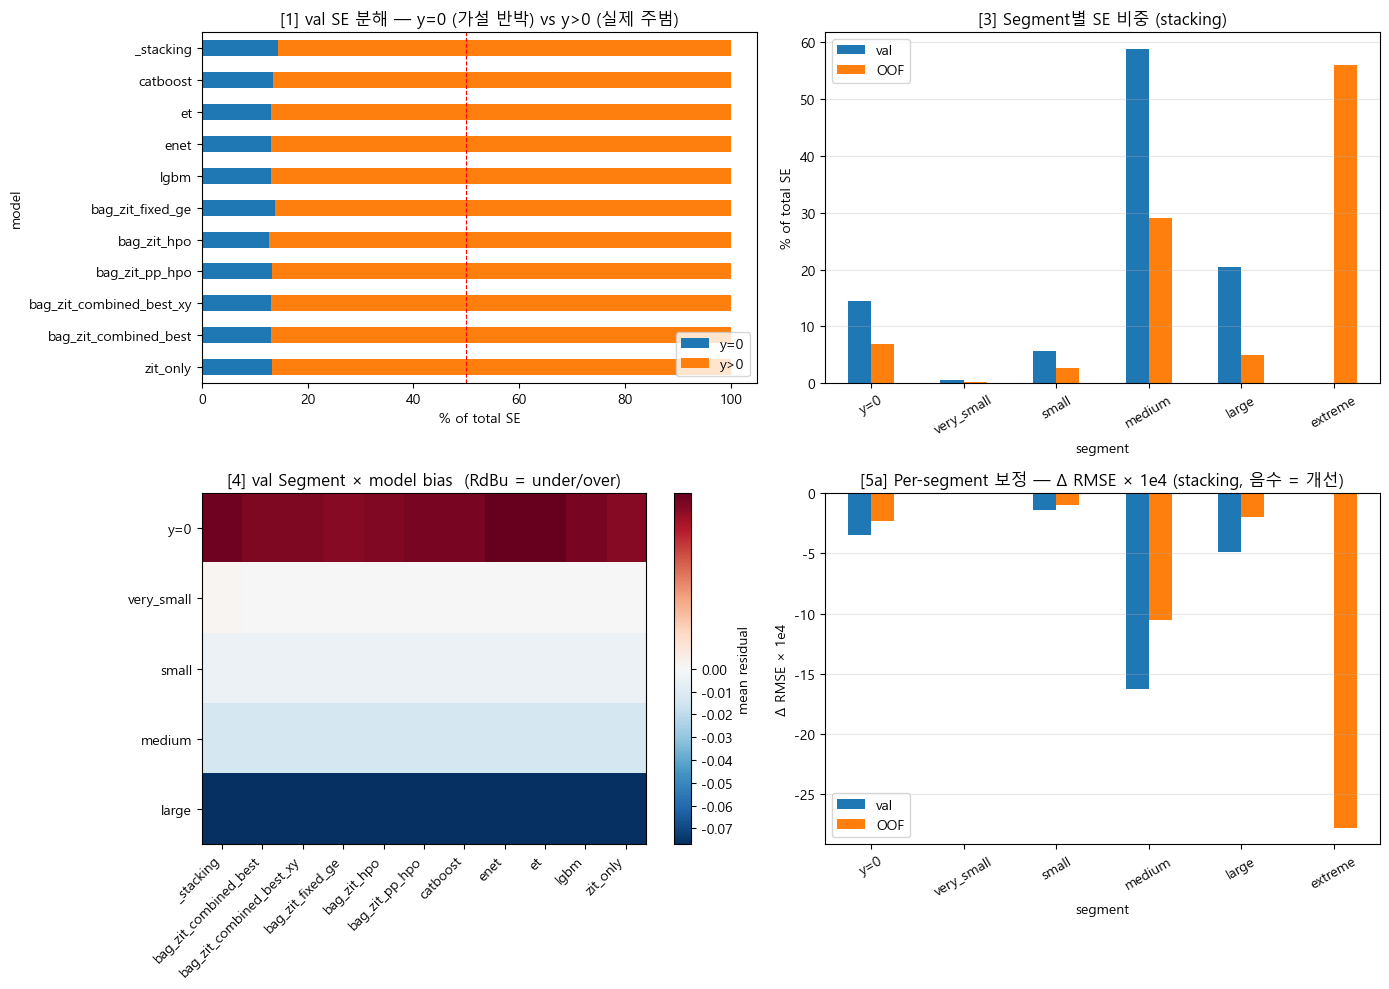

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) y=0 vs y>0 SE 비중 (val, 모든 모델)
ax = axes[0, 0]
df_p = se_val_df.set_index('model')[['pct_se_zero', 'pct_se_pos']]
df_p.plot(kind='barh', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('[1] val SE 분해 — y=0 (가설 반박) vs y>0 (실제 주범)')
ax.set_xlabel('% of total SE')
ax.legend(['y=0', 'y>0'], loc='lower right')
ax.axvline(50, color='red', linestyle='--', linewidth=0.8)

# (2) Segment별 SE 비중 (stacking, val + OOF)
ax = axes[0, 1]
seg_v = seg_val_df.query('model == "_stacking"').set_index('segment')['pct_total_se']
seg_o = seg_oof_df.query('model == "_stacking"').set_index('segment')['pct_total_se']
seg_order = [s[0] for s in SEGMENTS]
df_seg = pd.DataFrame({'val': seg_v, 'OOF': seg_o}).reindex([s for s in seg_order if s in seg_v.index or s in seg_o.index])
df_seg.plot(kind='bar', ax=ax, color=['C0', 'C1'])
ax.set_title('[3] Segment별 SE 비중 (stacking)')
ax.set_xlabel('segment')
ax.set_ylabel('% of total SE')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)

# (3) Segment × model 의 mean residual heatmap (val)
ax = axes[1, 0]
heat = bias_val.values
vmin, vmax = float(np.nanmin(heat)), float(np.nanmax(heat))
if vmin < 0 < vmax:
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
else:
    norm = None
im = ax.imshow(heat, aspect='auto', cmap='RdBu_r', norm=norm)
ax.set_xticks(range(len(bias_val.columns)))
ax.set_xticklabels(bias_val.columns, rotation=45, ha='right')
ax.set_yticks(range(len(bias_val.index)))
ax.set_yticklabels(bias_val.index)
ax.set_title('[4] val Segment × model bias  (RdBu = under/over)')
plt.colorbar(im, ax=ax, label='mean residual')

# (4) Per-segment bias 보정 효과 (val + OOF, stacking)
ax = axes[1, 1]
sub_v = per_val_df.query('model == "_stacking"').set_index('segment')['delta']
sub_o = per_oof_df.query('model == "_stacking"').set_index('segment')['delta']
df_corr = pd.DataFrame({'val': sub_v, 'OOF': sub_o}).reindex([s for s in seg_order if s in sub_v.index or s in sub_o.index]) * 1e4
df_corr.plot(kind='bar', ax=ax, color=['C0', 'C1'])
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('[5a] Per-segment 보정 — Δ RMSE × 1e4 (stacking, 음수 = 개선)')
ax.set_xlabel('segment')
ax.set_ylabel('Δ RMSE × 1e4')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
OUT_DIR = os.path.join(OUTPUT_DIR, 'final', 'error_analysis')
os.makedirs(OUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUT_DIR, 'error_analysis_summary.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. 산출물 저장 + obsolete 정리

In [9]:
OUT_DIR = os.path.join(OUTPUT_DIR, 'final', 'error_analysis')
os.makedirs(OUT_DIR, exist_ok=True)

pd.concat([se_oof_df, se_val_df]).to_csv(os.path.join(OUT_DIR, 'se_decomposition.csv'), index=False)
pd.concat([fp_oof_df, fp_val_df]).to_csv(os.path.join(OUT_DIR, 'fp_distribution.csv'), index=False)
pd.concat([seg_oof_df, seg_val_df]).to_csv(os.path.join(OUT_DIR, 'segment_decomposition.csv'), index=False)
bias_oof.to_csv(os.path.join(OUT_DIR, 'segment_bias_oof.csv'))
bias_val.to_csv(os.path.join(OUT_DIR, 'segment_bias_val.csv'))
pd.concat([per_oof_df, per_val_df]).to_csv(os.path.join(OUT_DIR, 'segment_correction_per.csv'), index=False)
pd.concat([full_oof_df, full_val_df]).to_csv(os.path.join(OUT_DIR, 'segment_correction_full.csv'), index=False)

# obsolete csv 정리 (1차 가설 검증으로 의미 잃은 것들)
obsolete = ['consensus_fp_count.csv', 'correction_simulation.csv']
obsolete += [os.path.basename(f) for f in glob.glob(os.path.join(OUT_DIR, 'consensus_fp_units_*.csv'))]
for ob in obsolete:
    p = os.path.join(OUT_DIR, ob)
    if os.path.exists(p):
        os.remove(p)
        print(f'  obsolete 삭제: {ob}')

# meta.json 갱신
top_seg_v = seg_val_df.query('model == "_stacking"').sort_values('pct_total_se', ascending=False).iloc[0]
top_seg_o = seg_oof_df.query('model == "_stacking"').sort_values('pct_total_se', ascending=False).iloc[0]
best_per_v = per_val_df.query('model == "_stacking"').sort_values('delta').iloc[0]
best_per_o = per_oof_df.query('model == "_stacking"').sort_values('delta').iloc[0]
full_v = full_val_df.query('model == "_stacking"').iloc[0]
full_o = full_oof_df.query('model == "_stacking"').iloc[0]

summary_meta = {
    'segments_definition': {s[0]: s[2] for s in SEGMENTS},
    'base_models':         BASE_COLS,
    'hypothesis_1_se_decomposition': {
        'val_stacking_pct_se_zero': float(se_val_df.query('model == "_stacking"').iloc[0]['pct_se_zero']),
        'oof_stacking_pct_se_zero': float(se_oof_df.query('model == "_stacking"').iloc[0]['pct_se_zero']),
        'verdict': 'rejected' if max(
            se_val_df.query('model == "_stacking"').iloc[0]['pct_se_zero'],
            se_oof_df.query('model == "_stacking"').iloc[0]['pct_se_zero']) < 50 else 'confirmed',
    },
    'top_segment_by_se_share_stacking': {
        'val': {'segment': top_seg_v['segment'], 'pct': float(top_seg_v['pct_total_se']), 'n': int(top_seg_v['n_unit'])},
        'oof': {'segment': top_seg_o['segment'], 'pct': float(top_seg_o['pct_total_se']), 'n': int(top_seg_o['n_unit'])},
    },
    'best_per_segment_correction_stacking': {
        'val': best_per_v.to_dict(),
        'oof': best_per_o.to_dict(),
    },
    'full_segment_correction_stacking': {
        'val_delta': float(full_v['delta']),
        'oof_delta': float(full_o['delta']),
        'val_rmse_corrected': float(full_v['rmse_corr']),
        'oof_rmse_corrected': float(full_o['rmse_corr']),
    },
}
with open(os.path.join(OUT_DIR, 'meta.json'), 'w', encoding='utf-8') as f:
    json.dump(summary_meta, f, indent=2, ensure_ascii=False, default=str)

print(f'\n저장 완료: {OUT_DIR}')
for f_ in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(os.path.join(OUT_DIR, f_)) / 1024
    print(f'  {f_:40s}  {sz:>10,.1f} KB')

  obsolete 삭제: consensus_fp_count.csv
  obsolete 삭제: correction_simulation.csv
  obsolete 삭제: consensus_fp_units_oof_tau0.005.csv
  obsolete 삭제: consensus_fp_units_val_tau0.005.csv

저장 완료: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\final\error_analysis
  error_analysis_summary.png                     134.4 KB
  fp_distribution.csv                              2.1 KB
  meta.json                                        1.7 KB
  se_decomposition.csv                             2.6 KB
  segment_bias_oof.csv                             1.6 KB
  segment_bias_val.csv                             1.4 KB
  segment_correction_full.csv                      1.8 KB
  segment_correction_per.csv                      13.6 KB
  segment_decomposition.csv                       18.9 KB


## 9. 결론 요약 + 다음 액션

In [10]:
print('=' * 90)
print(' Error Analysis — 가설 검증 + y>0 segment 진단')
print('=' * 90)

sse_v = se_val_df.query('model == "_stacking"').iloc[0]
sse_o = se_oof_df.query('model == "_stacking"').iloc[0]
print(f'\n[1] 1차 가설 "y=0이 RMSE 핵심" — 검증')
print(f'  OOF: y=0 SE 비중 = {sse_o["pct_se_zero"]:5.1f}%  |  y>0 SE 비중 = {sse_o["pct_se_pos"]:5.1f}%')
print(f'  val: y=0 SE 비중 = {sse_v["pct_se_zero"]:5.1f}%  |  y>0 SE 비중 = {sse_v["pct_se_pos"]:5.1f}%')
h1_rejected = max(sse_v['pct_se_zero'], sse_o['pct_se_zero']) < 50
print(f'  → 가설 {"❌ 반박 (y>0 가 진짜 주범)" if h1_rejected else "✓ 확인"}')

print(f'\n[3] y>0 segment별 RMSE 주범 (stacking, top 3)')
for label_, df_ in [('OOF', seg_oof_df), ('val', seg_val_df)]:
    top3 = df_.query('model == "_stacking"').sort_values('pct_total_se', ascending=False).head(3)
    print(f'  {label_}:')
    for _, row in top3.iterrows():
        print(f'    {row["segment"]:12s} ({row["range"]:14s}): n={int(row["n_unit"]):>5d}, '
              f'mean_y={row["mean_y"]:.6f}, mean_pred={row["mean_pred"]:.6f}, '
              f'RMSE_seg={row["rmse_segment"]:.6f}, SE 비중 {row["pct_total_se"]:5.1f}%')

print(f'\n[4] Bias 패턴 (10 base 평균, val)')
base_only = [c for c in bias_val.columns if c != '_stacking']
mean_bias_v = bias_val[base_only].mean(axis=1)
for seg_name, val in mean_bias_v.items():
    direction = 'under-predict' if val < 0 else 'over-predict'
    flag = '  ★' if abs(val) > 0.005 else ''
    print(f'    {seg_name:12s}: mean residual = {val:+.6f}  ({direction}){flag}')

fv = full_val_df.query('model == "_stacking"').iloc[0]
fo = full_oof_df.query('model == "_stacking"').iloc[0]
best_v = per_val_df.query('model == "_stacking"').sort_values('delta').iloc[0]
best_o = per_oof_df.query('model == "_stacking"').sort_values('delta').iloc[0]
print(f'\n[5] Oracle bias 보정 — RMSE 개선 상한')
print(f'  Per-segment best (val): "{best_v["segment"]}" Δ={best_v["delta"]:+.6f}')
print(f'  Per-segment best (OOF): "{best_o["segment"]}" Δ={best_o["delta"]:+.6f}')
print(f'  Full segment 동시 보정 (val): {fv["rmse_orig"]:.6f} → {fv["rmse_corr"]:.6f}  (Δ={fv["delta"]:+.6f})')
print(f'  Full segment 동시 보정 (OOF): {fo["rmse_orig"]:.6f} → {fo["rmse_corr"]:.6f}  (Δ={fo["delta"]:+.6f})')

print('\n' + '=' * 90)
print(' 다음 액션 추천')
print('=' * 90)
print(f'  1. Top segment ({top_seg_v["segment"] if top_seg_v["segment"] != "y=0" else top_seg_o["segment"]}) 의 unit 검토 → 어떤 wafer/feature 패턴인지')
print(f'  2. 그 segment 에 대해 specialized loss reweighting (예: y_weight = y / mean_y) 또는 Stage 2 conditional 정밀화')
print(f'  3. [4] 결과로 모든 base가 같은 방향으로 큰 bias 보이는 segment = 본질적 모델 한계 → 새 architecture 추가 시그널')
print('=' * 90)

 Error Analysis — 가설 검증 + y>0 segment 진단

[1] 1차 가설 "y=0이 RMSE 핵심" — 검증
  OOF: y=0 SE 비중 =   7.0%  |  y>0 SE 비중 =  93.0%
  val: y=0 SE 비중 =  14.5%  |  y>0 SE 비중 =  85.5%
  → 가설 ❌ 반박 (y>0 가 진짜 주범)

[3] y>0 segment별 RMSE 주범 (stacking, top 3)
  OOF:
    extreme      (> 0.5         ): n=    1, mean_y=1.000000, mean_pred=0.002119, RMSE_seg=0.997881, SE 비중  56.0%
    medium       ((0.01, 0.05]  ): n= 2326, mean_y=0.016491, mean_pred=0.002981, RMSE_seg=0.014916, SE 비중  29.1%
    y=0          (y == 0        ): n=18541, mean_y=0.000000, mean_pred=0.002323, RMSE_seg=0.002582, SE 비중   7.0%
  val:
    medium       ((0.01, 0.05]  ): n=  771, mean_y=0.016436, mean_pred=0.003012, RMSE_seg=0.014721, SE 비중  58.9%
    large        ((0.05, 0.5]   ): n=    8, mean_y=0.079620, mean_pred=0.003129, RMSE_seg=0.085134, SE 비중  20.4%
    y=0          (y == 0        ): n= 6178, mean_y=0.000000, mean_pred=0.002332, RMSE_seg=0.002577, SE 비중  14.5%

[4] Bias 패턴 (10 base 평균, val)
    y=0         : mean residual = +0.